# 1. EJEMPLO

## Paso 1. Importar librerías

In [63]:
#Importar librerías
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Paso 2. Obtención de los datos

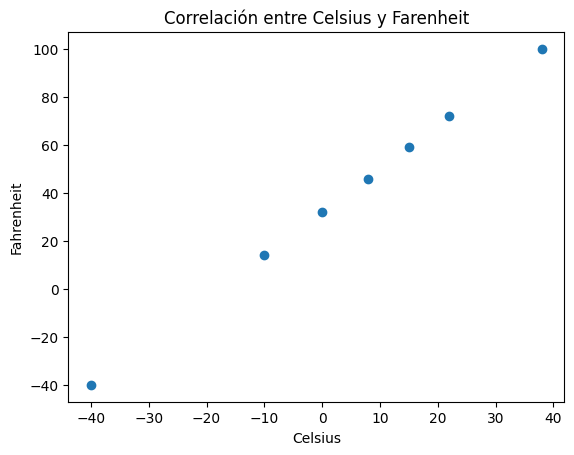

In [64]:
celsius = np.array([-40, -10, 0, 8, 15, 22, 38], dtype = float)
fahrenheit = np.array([-40, 14, 32, 46, 59, 72, 100], dtype = float)

#mostrar la correlación
plt.scatter(celsius, fahrenheit)

plt.title('Correlación entre Celsius y Farenheit')
plt.xlabel('Celsius')
plt.ylabel('Fahrenheit')

plt.show()

## 3. Selección de variabls independientes y objetivo

In [65]:
X_train = celsius
y_train = fahrenheit

## 4. Creación del modelo

In [66]:
print("Creando el modelo")
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(units=1))

Creando el modelo


## 5. Compilación del modelo

In [67]:
print("Compilando el modelo")
model.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

Compilando el modelo


## 6. Entrenamiento del modelo

In [68]:
print("Entrenando el modelo")
epochs_hist = model.fit(X_train, y_train, epochs=100, verbose=False)

Entrenando el modelo


## 7. Evaluación del modelo

In [69]:
print("Evaluando el modelo entrenado")
print("Keys:")
print(epochs_hist.history.keys())

Evaluando el modelo entrenado
Keys:
dict_keys(['loss'])


## 8. Gráfico

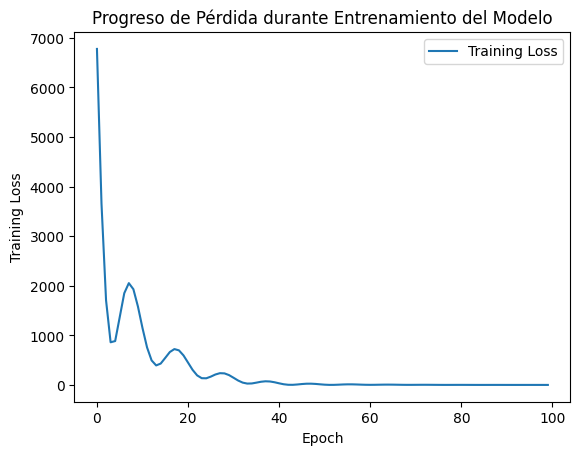

In [70]:
plt.plot(epochs_hist.history['loss'])
plt.title('Progreso de Pérdida durante Entrenamiento del Modelo')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(['Training Loss'])
plt.show()

In [71]:
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])
Temp_F = model.predict(Temp_C_array)

print("Temperatura de Predicción: " + str(Temp_F))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Temperatura de Predicción: [[211.30086]]


In [72]:
Temp_F = 9/5 * Temp_C + 32
print("Temperatura de Ecuación: " + str(Temp_F))

Temperatura de Ecuación: 212.0


# 2. EJERCICIO

In [73]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [74]:

import pandas as pd
import seaborn as sns

## 1. Importar CSV

In [75]:
df = pd.read_csv('celsius_a_fahrenheit.csv')
df.head()

,Celsius,Fahrenheit
0,-50,-58.0
1,-40,-40.0
2,-30,-22.0
3,-20,-4.0
4,-10,14.0


<Axes: xlabel='Celsius', ylabel='Fahrenheit'>

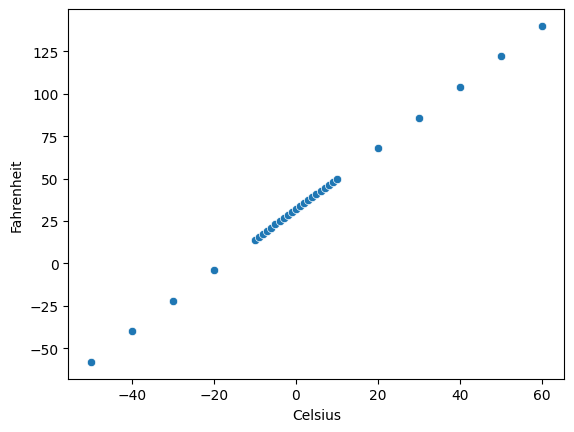

In [76]:
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df)

# 2. Selección de variables

In [77]:
X_train2 = df[['Celsius']]
y_train2 = df['Fahrenheit']

# 3. Crear el modelo

In [78]:
print("Creando el modelo")
model2 = tf.keras.Sequential()
model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(units=1))

Creando el modelo


# 4. Compilación del modelo

In [79]:
print("Compilando el modelo")
model2.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

Compilando el modelo


# 5. Entrenando el modelo

In [80]:
print("Entrenando el modelo")
epochs_hist2 = model2.fit(X_train2, y_train2, epochs=100, verbose=False)

Entrenando el modelo


# 6. Evaluar el modelo

In [81]:
print("Evaluando el modelo entrando")
print("Keys: ")
print(epochs_hist2.history.keys())

Evaluando el modelo entrando
Keys: 
dict_keys(['loss'])


# 7. Gráfico

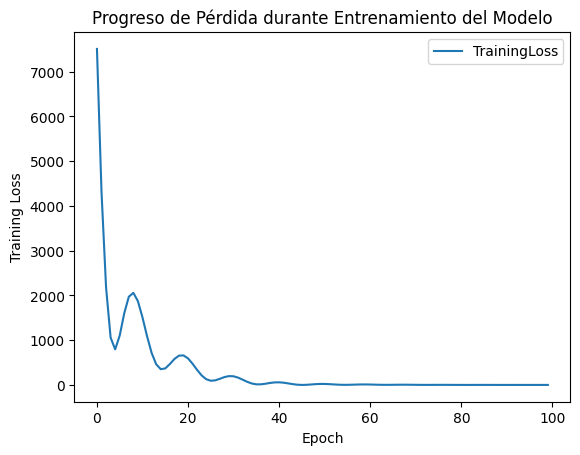

In [82]:
plt.plot(epochs_hist2.history['loss'])
plt.title('Progreso de Pérdida durante Entrenamiento del Modelo')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(['TrainingLoss'])
plt.show()

In [98]:
Temp_F2 = model2.predict(Temp_C_array)

print("Temperatura de Predicción: " + str(Temp_F2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Temperatura de Predicción: [[213.4391]]


In [99]:
Temp_F2 = 9/5 * Temp_C + 32
print("Temperatura de ecuación: " + str(Temp_F2))

Temperatura de ecuación: 212.0


## 8. Comparación modelos con la misma cantidad de capas

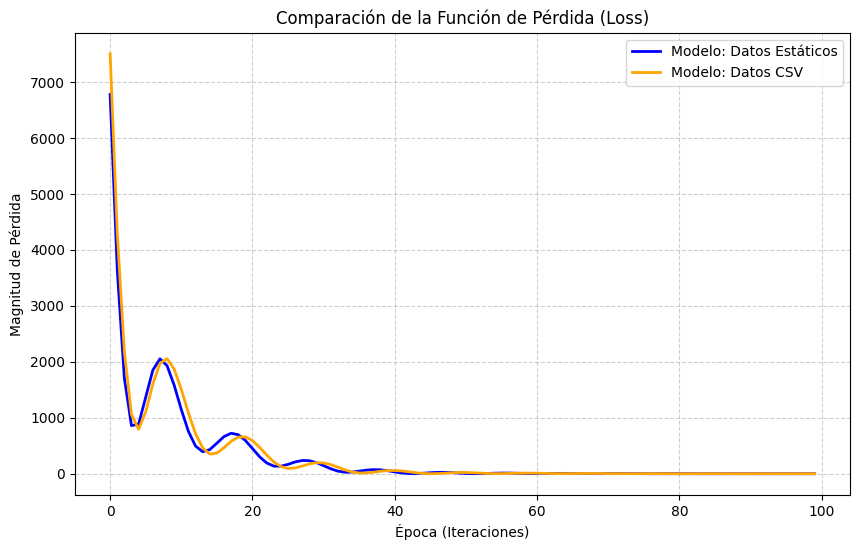

In [86]:
#tamaño
plt.figure(figsize=(10, 6))

# Pérdida del Modelo 1 (Datos Estáticos)
plt.plot(epochs_hist.history['loss'], label='Modelo: Datos Estáticos', color='blue', linewidth=2)

#Pérdida del Modelo 2 (Datos del CSV)
plt.plot(epochs_hist2.history['loss'], label='Modelo: Datos CSV', color='orange', linewidth=2)

plt.title('Comparación de la Función de Pérdida (Loss)')
plt.xlabel('Época (Iteraciones)')
plt.ylabel('Magnitud de Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Se observó que ambos modelos lograron aproximarse con un margen de error menor al 1%. El modelo estático obtuvo una predicción de 211.3 (error de 0.7), mientras que el modelo basado en CSV predijo 213.4 (error de 1.4).

## 9. Creación del Tercer modelo con Aumento de capas

In [92]:
entrada = tf.keras.layers.Input(shape=(1,))
oculta1 = tf.keras.layers.Dense(units=3)
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
model3 = tf.keras.Sequential([entrada,oculta1, oculta2, salida])

In [96]:
print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

[array([[-0.06296254, -1.05314   ,  0.14286803]], dtype=float32), array([-3.4543414, -3.6514282,  3.3829439], dtype=float32)]
[array([[ 1.5115309 ,  0.99273634, -0.00431908],
       [ 0.95587194,  0.33191672,  0.12552027],
       [-0.71277237, -0.09532494,  1.0893859 ]], dtype=float32), array([-3.6843588, -3.5342472,  3.4881527], dtype=float32)]
[array([[-1.202048 ],
       [-0.8046882],
       [ 0.6260526]], dtype=float32), array([3.4969976], dtype=float32)]


In [93]:
#Compilar
model3.compile(optimizer=tf.keras.optimizers.Adam(0.1),loss='mean_squared_error')

In [94]:
#Entrenar el modelo
print("Entrenando el modelo")
epochs_hist3 = model3.fit(X_train2, y_train2, epochs=100, verbose=False)

Entrenando el modelo


In [104]:
Temp_F3 = model3.predict(Temp_C_array)
print("Temperatura de Predicción: " + str(Temp_F3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Temperatura de Predicción: [[212.7733]]


In [105]:
Temp_F3 = 9/5 * Temp_C + 32
print("Temperatura de ecuación: " + str(Temp_F3))

Temperatura de ecuación: 212.0


## 10. Comparación Gráfica de los 3 modelos

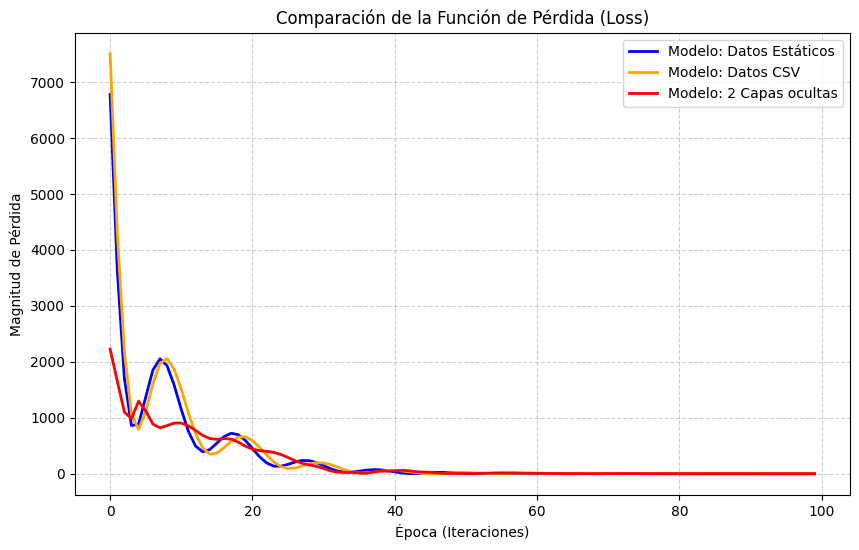

In [97]:
#tamaño
plt.figure(figsize=(10, 6))

# Pérdida del modelo 1 (Datos Estáticos)
plt.plot(epochs_hist.history['loss'], label='Modelo: Datos Estáticos', color='blue', linewidth=2)

#Pérdida del modelo 2 (Datos del CSV)
plt.plot(epochs_hist2.history['loss'], label='Modelo: Datos CSV', color='orange', linewidth=2)

#Pérdida del modelo 3 (CSV con 2 capas ocultas de 3 neuronas)
plt.plot(epochs_hist3.history['loss'], label='Modelo: 2 Capas ocultas', color='red', linewidth=2)

plt.title('Comparación de la Función de Pérdida (Loss)')
plt.xlabel('Época (Iteraciones)')
plt.ylabel('Magnitud de Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Al comparar los tres modelos, se observa que el Modelo 3 (Multicapa) logró mejorar significativamente la precisión sobre el Modelo 2, utilizando el mismo conjunto de datos (CSV). Esto demuestra que una estructura de red más profunda permite que el modelo procese mejor grandes volúmenes de datos, reduciendo el error de 1.4 a 0.7, igualando la precisión conseguida con datos estáticos simplificados.

# 3. Desarrollo de puntos

**1. El optimizador de algoritmo utilizado es Adam, pero existen otros como SGD y RMSProp, describe cada uno de ello y explica como pudieran cambiar los resultados de tu modelo.**    
   * Adam: Ajusta la velocidad de aprendizaje para cada peso de forma individual. Es el estándar porque es rápido y maneja muy bien el "ruido" en los datos.
   * SGD: Es el método más clásico. Actualiza los pesos de forma constante. Es más lento que Adam y puede quedarse "atrapado" en errores locales si la tasa de aprendizaje no está bien calibrada.
   * RMSProp: Similar a Adam, pero se enfoca en normalizar los gradientes. Es excelente para problemas donde los datos cambian con el tiempo.  

Con SGD probablemente necesitaría muchas más épocas para llegar al mismo 212°F. Al usar Adam, el modelo encuentra el camino al éxito mucho más rápido.  
  
**2. Describe porque es importante agregar una función de pérdida como 'mean_squared_error ', investiga que otra función de pérdida se puede implementar y como alteraría los resultados.**  
     Es importante porque es la forma que tiene el modelo de saber qué tan lejos está de la verdad.
* Mean Squared Error (MSE): Al elevar el error al cuadrado, castiga mucho más los errores grandes lo que obliga al modelo a priorizar corregir las desviaciones grandes rápidamente.
* Otra opción: Mean Absolute Error (MAE): En lugar de elevar al cuadrado, toma el valor absoluto ($|Real - Predicción|$). El modelo sería más "robusto" ante datos atípicos (outliers), pero le costaría más estabilizarse cerca del cero absoluto porque no "siente" la urgencia de corregir errores pequeños con tanta fuerza como el MSE.

**3. En las modificaciones realizadas,  cuantas epocas fueron 'suficientes' para que el modelo se considere entrenado para ponerlo en funcionamiento.**   
En la gráfica comparativa de pérdida se puede observar que los modelos simples logran estabilizarse a partir de la época 60, mientras que el modelo multicapa demuestra mayor eficiencia logrando una curva plana aproximadamente en la época 45.  

**4. ¿Por qué son importantes las epoch?**   
Una época es una pasada completa por todo el set de datos. Son importantes porque el cerebro de la IA necesita ver los ejemplos muchas veces, ajustando sus pesos en cada vuelta para que la fórmula final sea precisa. Muy pocas épocas causan Underfitting (el modelo no aprende) y demasiadas épocas pueden causar Overfitting (se memoriza los datos en lugar de aprender la lógica).  

**5. ¿Qué función de activación utiliza el modelo? ¿Es posible cambiarla? Si es así, cambia a una función RELU y muestra el resultado.**   

Actualmente, el modelo utiliza una activación lineal (o ninguna) por defecto en las capas Dense.

Sí se puede cambiar a RELU, pero RELU convierte todos los valores negativos en cero. Si tus grados Celsius bajan de cero, el modelo podría "morir" y no predecir nada.

In [106]:
#Creación de modelo usando RELU
entrada = tf.keras.layers.Input(shape=(1,))
oculta1 = tf.keras.layers.Dense(units=3, activation='relu')
oculta2 = tf.keras.layers.Dense(units=3, activation='relu')
salida = tf.keras.layers.Dense(units=1)
model_relu = tf.keras.Sequential([entrada,oculta1, oculta2, salida])

#Compilar
model_relu.compile(optimizer=tf.keras.optimizers.Adam(0.1),loss='mean_squared_error')

#Entrenar
epochs_hist_relu = model_relu.fit(X_train2, y_train2, epochs=100, verbose=False)

In [107]:
#Evaluar
Temp_F_relu = model_relu.predict(Temp_C_array)
print("Temperatura de Predicción: " + str(Temp_F_relu))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Temperatura de Predicción: [[212.05513]]


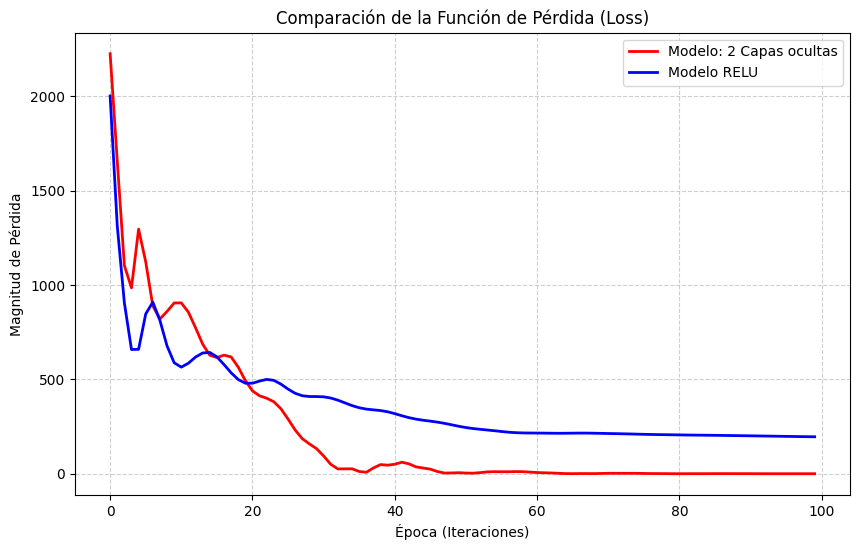

In [110]:
plt.figure(figsize=(10, 6))

#Pérdida del modelo 3 (CSV con 2 capas ocultas de 3 neuronas)
plt.plot(epochs_hist3.history['loss'], label='Modelo: 2 Capas ocultas', color='red', linewidth=2)

#Pérdida del modelo usando RELU
#Pérdida del modelo 3 (CSV con 2 capas ocultas de 3 neuronas)
plt.plot(epochs_hist_relu.history['loss'], label='Modelo RELU', color='blue', linewidth=2)

plt.title('Comparación de la Función de Pérdida (Loss)')
plt.xlabel('Época (Iteraciones)')
plt.ylabel('Magnitud de Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [119]:
Temp_C_array = np.array([[-10]])
Temp_F_model2 = model2.predict(Temp_C_array)
print('Estimación del modelo 2',Temp_F_model2)
Temp_F_relu = model_relu.predict(Temp_C_array)
print('Estimación del modelo RELU',Temp_F_relu)
print('Valor Real: ', 9/5 * (-10) + 32 )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Estimación del modelo 2 [[13.654573]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Estimación del modelo RELU [[11.929985]]
Valor Real:  14.0


Aunque el modelo con activación ReLU logra realizar predicciones, su curva de pérdida demuestra que no es la función óptima para este problema. Al ser una relación puramente lineal (1.8C+32), el uso de ReLU introduce una complejidad innecesaria y ralentiza la convergencia, impidiendo que el error se acerque a cero en las primeras 100 épocas debido a la naturaleza de la función que anula los valores negativos.